<a href="https://colab.research.google.com/github/prithvivinodnair/long-read-aligner-benchmark/blob/main/notebooks/week1_week3_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Setup – Long-Read Aligner Benchmark

This notebook sets up the environment for the project:
- Clones the `long-read-aligner-benchmark` GitHub repo
- Installs Python dependencies
- Prepares folders for reference genome, annotations, and simulated reads
- Installs NanoSim-H for Nanopore-like read simulation
- Installs Minimap2 and runs a first test alignment

This work corresponds to Week 1 tasks:
- Set up environment
- Download/add genome + GFF
- Generate simulated reads
- Run first aligner


In [8]:
!git clone https://github.com/prithvivinodnair/long-read-aligner-benchmark.git
%cd long-read-aligner-benchmark

!ls -R


Cloning into 'long-read-aligner-benchmark'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 101 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 10.17 MiB | 2.65 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/long-read-aligner-benchmark
.:
aiusage.md  data  environment  notebooks  README.md  results  scripts

./data:
annotations  reference	simulated_reads

./data/annotations:

./data/reference:
README_reference.txt

./data/simulated_reads:
chr22_simulated.fa

./environment:
requirements.txt  setup_instructions.md

./notebooks:
README.md  week1_setup.ipynb

./results:
figures  logs

./results/figures:

./results/logs:
minimap2_week1_chr22_simulated.sam

./scripts:
evaluate_accuracy.py  run_minimap2.sh  run_ngmlr.sh  run_winnowmap.sh


In [9]:
# Install Python dependencies listed in environment/requirements.txt
!pip install -r environment/requirements.txt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python environment is ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 39.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pybedtools: filename=pybedtools-0.12.0-cp312-cp312-linux_x86_64.whl size=14340822 sha256=bb67268dbad55485a65a9e9e32d52d20ba5fa3435e99c04862273887bf24feda
  Stored in directory: /root/.cache/pip/wheels/ac/38/f2/960d79e44a92afc0d34a4727c856ce0149ac23c3dcda174356
Successfully built pybedtools
Python environment is ready.


In [10]:
import os

folders = [
    "data",
    "data/reference",
    "data/annotations",
    "data/simulated_reads",
    "results",
    "results/logs",
    "results/figures"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Data and results folders are ready.")
!ls -R


Data and results folders are ready.
.:
aiusage.md  data  environment  notebooks  README.md  results  scripts

./data:
annotations  reference	simulated_reads

./data/annotations:

./data/reference:
README_reference.txt

./data/simulated_reads:
chr22_simulated.fa

./environment:
requirements.txt  setup_instructions.md

./notebooks:
README.md  week1_setup.ipynb

./results:
figures  logs

./results/figures:

./results/logs:
minimap2_week1_chr22_simulated.sam

./scripts:
evaluate_accuracy.py  run_minimap2.sh  run_ngmlr.sh  run_winnowmap.sh


In [11]:
from google.colab import files
import shutil
import os

print("Please upload your reference FASTA file (e.g., chr22.fa.gz).")
uploaded = files.upload()  # choose chr22.fa.gz from your computer

for filename in uploaded.keys():
    dest = f"data/reference/{filename}"
    shutil.move(filename, dest)
    print(f"Moved {filename} -> {dest}")

print("\nReference folder contents:")
!ls -lh data/reference


Please upload your reference FASTA file (e.g., chr22.fa.gz).


Saving chr22.fa.gz to chr22.fa.gz
Moved chr22.fa.gz -> data/reference/chr22.fa.gz

Reference folder contents:
total 12M
-rw-r--r-- 1 root root 12M Dec  1 01:51 chr22.fa.gz
-rw-r--r-- 1 root root 223 Dec  1 01:49 README_reference.txt


In [12]:
!ls -lh data/reference


total 12M
-rw-r--r-- 1 root root 12M Dec  1 01:51 chr22.fa.gz
-rw-r--r-- 1 root root 223 Dec  1 01:49 README_reference.txt


In [13]:
!gunzip data/reference/chr22.fa.gz


In [14]:
!ls -lh data/reference


total 50M
-rw-r--r-- 1 root root 50M Dec  1 01:51 chr22.fa
-rw-r--r-- 1 root root 223 Dec  1 01:49 README_reference.txt


In [15]:
# Install Biopython for FASTA handling
!pip install biopython

from Bio import SeqIO
import os
import random

# Locate the reference FASTA
ref_dir = "data/reference"
ref_files = [f for f in os.listdir(ref_dir) if f.endswith((".fa", ".fasta", ".fna"))]

if not ref_files:
    raise FileNotFoundError("No FASTA found in data/reference. Make sure chr22.fa is there.")

reference_fasta = os.path.join(ref_dir, ref_files[0])
print("Using reference FASTA:", reference_fasta)

# Read the first (and likely only) sequence
record = next(SeqIO.parse(reference_fasta, "fasta"))
genome_seq = str(record.seq)
genome_len = len(genome_seq)
print("Reference length:", genome_len)

# Simulation parameters
n_reads = 2000       # number of reads
read_len = 10000     # length of each read
error_rate = 0.05    # 5% bases mutated to introduce noise

out_path = "data/simulated_reads/chr22_simulated.fa"

def mutate_base(b):
    bases = ["A", "C", "G", "T"]
    bases = [x for x in bases if x != b.upper()]
    return random.choice(bases)

with open(out_path, "w") as out_f:
    for i in range(n_reads):
        # pick random start so the read fits within the chromosome
        start = random.randint(0, genome_len - read_len - 1)
        seq = list(genome_seq[start:start+read_len])

        # introduce random substitutions
        for j in range(len(seq)):
            if random.random() < error_rate and seq[j] in "ACGTacgt":
                seq[j] = mutate_base(seq[j])

        read_seq = "".join(seq)
        out_f.write(f">read_{i}_start{start}_len{read_len}\n")
        # wrap sequence to 80 chars per line
        for k in range(0, len(read_seq), 80):
            out_f.write(read_seq[k:k+80] + "\n")

print(f"Simulated {n_reads} long reads written to {out_path}")

!ls -lh data/simulated_reads


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.3 MB/s eta 0:00:00
Using reference FASTA: data/reference/chr22.fa
Reference length: 50818468
Simulated 2000 long reads written to data/simulated_reads/chr22_simulated.fa
total 20M
-rw-r--r-- 1 root root 20M Dec  1 01:51 chr22_simulated.fa


In [16]:
# Install Minimap2
!apt-get update -y
!apt-get install -y minimap2

# Check version
!minimap2 --version


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,153 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/u

In [17]:
import os

# Find simulated reads FASTA
sim_dir = "data/simulated_reads"
sim_files = [f for f in os.listdir(sim_dir) if f.endswith((".fa", ".fasta"))]

if not sim_files:
    raise FileNotFoundError("No simulated FASTA reads found in data/simulated_reads.")

reads_fasta = os.path.join(sim_dir, sim_files[0])
print("Using simulated reads:", reads_fasta)

# Find reference FASTA
ref_dir = "data/reference"
ref_files = [f for f in os.listdir(ref_dir) if f.endswith((".fa", ".fasta", ".fna"))]

if not ref_files:
    raise FileNotFoundError("No FASTA reference found in data/reference.")

reference_fasta = os.path.join(ref_dir, ref_files[0])
print("Using reference:", reference_fasta)

# Ensure results/logs exists
os.makedirs("results/logs", exist_ok=True)
sam_out = "results/logs/minimap2_week1_chr22_simulated.sam"

# Run Minimap2 in ONT mode (-x map-ont) and output SAM
!minimap2 -x map-ont -a {reference_fasta} {reads_fasta} > {sam_out}

print("\nMinimap2 alignment complete. Output SAM:", sam_out)
!head -n 10 {sam_out}


Using simulated reads: data/simulated_reads/chr22_simulated.fa
Using reference: data/reference/chr22.fa
[M::mm_idx_gen::5.495*0.61] collected minimizers
[M::mm_idx_gen::7.333*0.61] sorted minimizers
[M::main::7.333*0.61] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::7.665*0.61] mid_occ = 238
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 1
[M::mm_idx_stat::7.892*0.61] distinct minimizers: 5012420 (87.89% are singletons); average occurrences: 1.472; average spacing: 6.888; total length: 50818468
[M::worker_pipeline::22.001*1.13] mapped 2000 sequences
[M::main] Version: 2.24-r1122
[M::main] CMD: minimap2 -x map-ont -a data/reference/chr22.fa data/simulated_reads/chr22_simulated.fa
[M::main] Real time: 22.050 sec; CPU: 24.877 sec; Peak RSS: 0.423 GB

Minimap2 alignment complete. Output SAM: results/logs/minimap2_week1_chr22_simulated.sam
@SQ	SN:chr22	LN:50818468
@PG	ID:minimap2	PN:minimap2	VN:2.24-r1122	CL:minimap2 -x map-ont -a data/reference/chr22.fa 

In [18]:
from google.colab import files

# Download reference FASTA
files.download("data/reference/chr22.fa")

# Download simulated reads
files.download("data/simulated_reads/chr22_simulated.fa")

# Download SAM alignment
files.download("results/logs/minimap2_week1_chr22_simulated.sam")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Week 2: setup for accuracy metrics
!pip install pysam

import os
import re
import pandas as pd
import pysam

# Paths to data and results
sam_path = "results/logs/minimap2_week1_chr22_simulated.sam"
ref_path = "data/reference/chr22.fa"

print("SAM file exists:", os.path.exists(sam_path))
print("Reference exists:", os.path.exists(ref_path))


SAM file exists: True
Reference exists: True


In [20]:
# Install pysam (only needs to be done once per session)
!pip install pysam

import pysam
import re
import math
import pandas as pd
import math

def parse_true_start(read_name: str):
    """
    Extract the true start coordinate from read name, e.g.:
    'read_0_start22021245_len10000' -> 22021245
    Returns None if pattern not found.
    """
    m = re.search(r"start(\d+)", read_name)
    if m:
        return int(m.group(1))
    return None

# Open SAM with pysam
samfile = pysam.AlignmentFile(sam_path, "r")

records = []

for aln in samfile.fetch(until_eof=True):
    # Skip unmapped reads just in case
    if aln.is_unmapped:
        continue

    read_name = aln.query_name
    true_start = parse_true_start(read_name)

    # pysam is 0-based, SAM POS is 1-based
    aligned_start = aln.reference_start + 1  # convert to 1-based

    # try to get error rate from 'de' tag (minimap2), else from NM/edit distance
    error_rate = None
    try:
        error_rate = aln.get_tag("de")  # fraction of differences
    except KeyError:
        # fallback: compute from NM if available and read length
        try:
            nm = aln.get_tag("NM")
            read_len = aln.query_length
            if read_len and read_len > 0:
                error_rate = nm / read_len
        except KeyError:
            error_rate = math.nan

    abs_pos_error = None
    if true_start is not None:
        abs_pos_error = abs(aligned_start - true_start)

    records.append({
        "read_name": read_name,
        "true_start": true_start,
        "aligned_start": aligned_start,
        "abs_pos_error": abs_pos_error,
        "mapq": aln.mapping_quality,
        "error_rate": error_rate
    })

samfile.close()

import pandas as pd
df_minimap2 = pd.DataFrame(records)
df_minimap2.head()


,read_name,true_start,aligned_start,abs_pos_error,mapq,error_rate
0,read_0_start31365178_len10000,31365178,31365179,1,60,0.0501
1,read_3_start42267684_len10000,42267684,42267685,1,60,0.0520
2,read_4_start34134458_len10000,34134458,34134461,3,60,0.0512
3,read_5_start32554133_len10000,32554133,32554134,1,60,0.0535
4,read_6_start44559084_len10000,44559084,44559085,1,60,0.0510


In [21]:
# Week 2 – Cell 3: summary statistics for Minimap2

print("Number of aligned reads:", len(df_minimap2))

print("\nAbsolute position error (bp):")
print(df_minimap2["abs_pos_error"].describe())

print("\nError rate (fraction differences per base):")
print(df_minimap2["error_rate"].describe())

print("\nMAPQ (mapping quality) summary:")
print(df_minimap2["mapq"].describe())

# How many reads are basically correctly placed?
within_5bp = (df_minimap2["abs_pos_error"] <= 5).mean()
within_50bp = (df_minimap2["abs_pos_error"] <= 50).mean()

print(f"\nFraction of reads with start within 5 bp of true:  {within_5bp:.3f}")
print(f"Fraction of reads with start within 50 bp of true: {within_50bp:.3f}")


Number of aligned reads: 1682

Absolute position error (bp):
count    1.682000e+03
mean     1.422320e+05
std      6.522926e+05
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      6.285768e+06
Name: abs_pos_error, dtype: float64

Error rate (fraction differences per base):
count    1682.000000
mean        0.050680
std         0.003325
min         0.042200
25%         0.048700
50%         0.050300
75%         0.052000
max         0.076400
Name: error_rate, dtype: float64

MAPQ (mapping quality) summary:
count    1682.000000
mean       54.702735
std        16.788132
min         0.000000
25%        60.000000
50%        60.000000
75%        60.000000
max        60.000000
Name: mapq, dtype: float64

Fraction of reads with start within 5 bp of true:  0.894
Fraction of reads with start within 50 bp of true: 0.913


In [22]:
# Week 2 – Cell 4a: install intervaltree and create a synthetic chr22 GFF

!pip install intervaltree

import os

os.makedirs("data/annotations", exist_ok=True)

gff_text = """##gff-version 3
chr22\tsynthetic\texon\t1000000\t1010000\t.\t+\t.\tID=exon1;gene=GENE1
chr22\tsynthetic\texon\t5000000\t5008000\t.\t-\t.\tID=exon2;gene=GENE2
chr22\tsynthetic\texon\t12000000\t12005000\t.\t+\t.\tID=exon3;gene=GENE3
chr22\tsynthetic\texon\t20000000\t20010000\t.\t-\t.\tID=exon4;gene=GENE4
chr22\tsynthetic\texon\t30000000\t30006000\t.\t+\t.\tID=exon5;gene=GENE5
chr22\tsynthetic\texon\t40000000\t40009000\t.\t-\t.\tID=exon6;gene=GENE6
chr22\tsynthetic\texon\t45000000\t45005000\t.\t+\t.\tID=exon7;gene=GENE7
chr22\tsynthetic\texon\t48000000\t48007000\t.\t-\t.\tID=exon8;gene=GENE8
"""

gff_path = "data/annotations/chr22.gff3"
with open(gff_path, "w") as f:
    f.write(gff_text)

print("Wrote synthetic GFF to:", gff_path)
!cat data/annotations/chr22.gff3


  Preparing metadata (setup.py) ... done
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26098 sha256=153b5e8362845f177cc8fe120c1d006c01951fd94f062d160690bf7f072c2f3e
  Stored in directory: /root/.cache/pip/wheels/65/c3/c3/238bf93c243597857edd94ddb0577faa74a8e16e9585896e83
Successfully built intervaltree
Wrote synthetic GFF to: data/annotations/chr22.gff3
##gff-version 3
chr22	synthetic	exon	1000000	1010000	.	+	.	ID=exon1;gene=GENE1
chr22	synthetic	exon	5000000	5008000	.	-	.	ID=exon2;gene=GENE2
chr22	synthetic	exon	12000000	12005000	.	+	.	ID=exon3;gene=GENE3
chr22	synthetic	exon	20000000	20010000	.	-	.	ID=exon4;gene=GENE4
chr22	synthetic	exon	30000000	30006000	.	+	.	ID=exon5;gene=GENE5
chr22	synthetic	exon	40000000	40009000	.	-	.	ID=exon6;gene=GENE6
chr22	synthetic	exon	45000000	45005000	.	+	.	ID=exon7;gene=GENE7
chr22	synthetic	exon	48000000	48007000	.	-	.	ID=exon8;gene=GENE8


In [24]:
# Week 2 – Cell 4b: Coding vs noncoding classification using synthetic GFF (FIXED)

from intervaltree import IntervalTree
import pandas as pd

gff_path = "data/annotations/chr22.gff3"

# Load the synthetic GFF
gff = pd.read_csv(
    gff_path,
    sep="\t",
    comment="#",
    header=None,
    names=["seqid","source","type","start","end","score","strand","phase","attributes"]
)

# Keep only exons (coding regions)
exons = gff[gff["type"] == "exon"].copy()

# Build interval tree of coding regions
tree = IntervalTree()
for _, row in exons.iterrows():
    tree[row["start"]:row["end"]] = True

def is_coding(pos: int) -> bool:
    if pos is None:
        return False
    # check if this 1bp position overlaps any exon interval
    hits = tree.overlap(pos, pos + 1)
    return len(hits) > 0

# Apply to your Minimap2 dataframe
df_minimap2["is_coding"] = df_minimap2["aligned_start"].apply(is_coding)
df_minimap2["region"] = df_minimap2["is_coding"].map({True: "coding", False: "noncoding"})

df_minimap2["region"].value_counts()


,count
region,
noncoding,1680
coding,2


In [25]:
# Week 2 – Cell 5: Compare coding vs noncoding error patterns

# Basic counts
print("Region counts:")
print(df_minimap2["region"].value_counts(), "\n")

# Grouped summaries
group_summary = df_minimap2.groupby("region")[["error_rate", "abs_pos_error", "mapq"]].agg(
    ["mean", "median", "std", "min", "max", "count"]
)

group_summary


Region counts:
region
noncoding    1680
coding          2
Name: count, dtype: int64 



error_rate                                          abs_pos_error  \
                mean   median       std     min     max count          mean   
region                                                                        
coding      0.050150  0.05015  0.000495  0.0498  0.0505     2       1.00000   
noncoding   0.050681  0.05030  0.003327  0.0422  0.0764  1680  142401.28631   

                                                         mapq         \
          median            std min      max count       mean median   
region                                                                 
coding       1.0       0.000000   1        1     2  60.000000   60.0   
noncoding    1.0  652662.453038   1  6285768  1680  54.696429   60.0   

                                    
                 std min max count  
region                              
coding      0.000000  60  60     2  
noncoding  16.797132   0  60  1680

In [28]:
# Try installing ngmlr from Ubuntu/Debian repositories
!apt-get update -y
!apt-get install -y ngmlr

# Check if it's installed and on PATH
!which ngmlr || echo "ngmlr not found on PATH"
!ngmlr --version || echo "ngmlr command failed"


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [29]:
# Week 2 – NGMLR Cell2: Align simulated reads with NGMLR

ngmlr_path = "ngmlr"  # installed via apt, on PATH

!{ngmlr_path} -r data/reference/chr22.fa \
              -q data/simulated_reads/chr22_simulated.fa \
              -o results/logs/ngmlr_chr22.sam \
              -x ont

# Check that the SAM file was created
!ls -lh results/logs/ngmlr_chr22.sam


Streaming output truncated to the last 5000 lines.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2nd best alignment information.
When maskLen < 15, the function ssw_align doesn't return 2n

In [30]:
# Week 2 – NGMLR Cell3: Parse SAM and compute per-read metrics

ngmlr_sam = "results/logs/ngmlr_chr22.sam"
samfile = pysam.AlignmentFile(ngmlr_sam, "r")

ngmlr_records = []

for aln in samfile.fetch(until_eof=True):
    if aln.is_unmapped:
        continue

    read_name = aln.query_name
    true_start = parse_true_start(read_name)
    aligned_start = aln.reference_start + 1  # convert to 1-based

    # Use NM tag for error estimate (edit distance / read length)
    try:
        nm = aln.get_tag("NM")
        read_len = aln.query_length
        error_rate = nm / read_len if read_len and read_len > 0 else None
    except KeyError:
        error_rate = None

    abs_pos_error = None
    if true_start is not None:
        abs_pos_error = abs(aligned_start - true_start)

    ngmlr_records.append({
        "read_name": read_name,
        "true_start": true_start,
        "aligned_start": aligned_start,
        "abs_pos_error": abs_pos_error,
        "mapq": aln.mapping_quality,
        "error_rate": error_rate
    })

samfile.close()

import pandas as pd
df_ngmlr = pd.DataFrame(ngmlr_records)
df_ngmlr.head()


,read_name,true_start,aligned_start,abs_pos_error,mapq,error_rate
0,read_0_start31365178_len10000,31365178,31365185,7,60,0.0500
1,read_3_start42267684_len10000,42267684,42267685,1,60,0.0520
2,read_4_start34134458_len10000,34134458,34134465,7,60,0.0512
3,read_5_start32554133_len10000,32554133,32554134,1,60,0.0535
4,read_6_start44559084_len10000,44559084,44559089,5,59,0.0510


In [31]:
# Week 2 – NGMLR Cell4: classify NGMLR reads as coding vs noncoding

df_ngmlr["is_coding"] = df_ngmlr["aligned_start"].apply(is_coding)
df_ngmlr["region"] = df_ngmlr["is_coding"].map({True: "coding", False: "noncoding"})

df_ngmlr["region"].value_counts()


,count
region,
noncoding,1516
coding,2


In [32]:
# Week 2 – NGMLR Cell5: region-wise summary metrics

ngmlr_summary = df_ngmlr.groupby("region")[["error_rate", "abs_pos_error", "mapq"]].describe()
ngmlr_summary


error_rate                                                           \
               count      mean       std     min       25%      50%       75%   
region                                                                          
coding           2.0  0.050150  0.000495  0.0498  0.049975  0.05015  0.050325   
noncoding     1516.0  0.049832  0.003209  0.0112  0.048500  0.05000  0.051500   

                  abs_pos_error             ...                 mapq  \
              max         count       mean  ...  75%     max   count   
region                                      ...                        
coding     0.0505           2.0   4.000000  ...  5.5     7.0     2.0   
noncoding  0.0577        1516.0  16.885884  ...  6.0  6406.0  1516.0   

                                                               
                mean        std   min   25%   50%   75%   max  
region                                                         
coding     60.000000   0.000000  60.0  60.0  60.0  60.0  60.0  
noncoding  55.168206  13.952255   1.0  60.0  60.0  60.0  60.0  

[2 rows x 24 columns]

In [33]:
# Install LAST aligner (third tool)
!apt-get update -y
!apt-get install -y last-align

# Check it installed
!which lastal || echo "lastal not found"
!lastal -h | head -n 5


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [34]:
# LAST Cell2 – build database on chr22 reference
!mkdir -p results/logs

# Build a LAST database named "chr22_lastdb" from the reference FASTA
!lastdb -uNEAR -R01 results/logs/chr22_lastdb data/reference/chr22.fa

# Check that database files exist
!ls results/logs | grep chr22_lastdb || echo "DB files not found"


chr22_lastdb.bck
chr22_lastdb.des
chr22_lastdb.prj
chr22_lastdb.sds
chr22_lastdb.ssp
chr22_lastdb.suf
chr22_lastdb.tis


In [36]:
# Create a smaller FASTA with the first 500 simulated reads for LAST
from Bio import SeqIO
from itertools import islice
import os

input_fa = "data/simulated_reads/chr22_simulated.fa"
small_fa = "data/simulated_reads/chr22_simulated_500.fa"

os.makedirs("data/simulated_reads", exist_ok=True)

records = list(islice(SeqIO.parse(input_fa, "fasta"), 500))
SeqIO.write(records, small_fa, "fasta")

print(f"Wrote {len(records)} reads to {small_fa}")


Wrote 500 reads to data/simulated_reads/chr22_simulated_500.fa


In [37]:
# LAST Cell3 (updated) – align 500 reads with LAST and convert to SAM

# Align 500 reads
!lastal -P4 results/logs/chr22_lastdb data/simulated_reads/chr22_simulated_500.fa > results/logs/last_chr22_500.maf

# Convert MAF to SAM
!maf-convert sam results/logs/last_chr22_500.maf > results/logs/last_chr22_500.sam

# Check SAM file
!ls -lh results/logs/last_chr22_500.sam


-rw-r--r-- 1 root root 566M Dec  1 02:40 results/logs/last_chr22_500.sam


In [41]:
# LAST Cell4 – custom SAM parser (no pysam) for 500-read LAST SAM

import math
import pandas as pd

last_sam = "results/logs/last_chr22_500.sam"

last_records = []

with open(last_sam, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("@"):
            # header or empty line
            continue

        parts = line.split("\t")
        # SAM must have at least 11 fields: QNAME, FLAG, RNAME, POS, MAPQ, CIGAR, RNEXT, PNEXT, TLEN, SEQ, QUAL
        if len(parts) < 11:
            # this also safely skips any truncated partial line at the end
            continue

        qname = parts[0]
        flag = int(parts[1])
        rname = parts[2]
        pos = parts[3]
        mapq = parts[4]
        cigar = parts[5]
        seq = parts[9]

        # Skip unmapped reads (RNAME="*" or POS="0")
        if rname == "*" or pos == "0":
            continue

        read_name = qname
        true_start = parse_true_start(read_name)
        aligned_start = int(pos)  # SAM is already 1-based
        mapq_val = int(mapq)

        # find NM tag in optional fields
        nm_val = None
        for field in parts[11:]:
            if field.startswith("NM:i:"):
                try:
                    nm_val = int(field[5:])
                except ValueError:
                    nm_val = None
                break

        read_len = len(seq)
        error_rate = math.nan
        if nm_val is not None and read_len > 0:
            error_rate = nm_val / read_len

        abs_pos_error = None
        if true_start is not None:
            abs_pos_error = abs(aligned_start - true_start)

        last_records.append({
            "read_name": read_name,
            "true_start": true_start,
            "aligned_start": aligned_start,
            "abs_pos_error": abs_pos_error,
            "mapq": mapq_val,
            "error_rate": error_rate
        })

df_last = pd.DataFrame(last_records)
df_last.head()


,read_name,true_start,aligned_start,abs_pos_error,mapq,error_rate
0,read_0_start31365178_len10000,31365178,31365179,1,255,0.050100
1,read_0_start31365178_len10000,31365178,41089457,9724279,255,0.168190
2,read_0_start31365178_len10000,31365178,46603277,15238099,255,0.168519
3,read_0_start31365178_len10000,31365178,32638965,1273787,255,0.098592
4,read_0_start31365178_len10000,31365178,29094625,2270553,255,0.111864


In [42]:
# LAST Cell5 – coding vs noncoding + summary

df_last["is_coding"] = df_last["aligned_start"].apply(is_coding)
df_last["region"] = df_last["is_coding"].map({True: "coding", False: "noncoding"})

print("Region counts (LAST):")
print(df_last["region"].value_counts(), "\n")

last_summary = df_last.groupby("region")[["error_rate", "abs_pos_error", "mapq"]].describe()
last_summary


Region counts (LAST):
region
noncoding    1459251
coding           935
Name: count, dtype: int64 



error_rate                                                         \
               count      mean       std  min       25%       50%       75%   
region                                                                        
coding         935.0  0.139024  0.047811  0.0  0.115025  0.147727  0.174791   
noncoding  1459251.0  0.137053  0.051334  0.0  0.107692  0.149310  0.175676   

                    abs_pos_error                ...                          \
                max         count          mean  ...         75%         max   
region                                           ...                           
coding     0.235669         935.0  1.192648e+07  ...  18335332.5  37261088.0   
noncoding  0.280612     1459251.0  1.006697e+07  ...  15897005.5  40151859.0   

                mapq                                                 
               count   mean  std    min    25%    50%    75%    max  
region                                                               
coding         935.0  255.0  0.0  255.0  255.0  255.0  255.0  255.0  
noncoding  1459251.0  255.0  0.0  255.0  255.0  255.0  255.0  255.0  

[2 rows x 24 columns]

In [43]:
# Week 3 – Cell 1: Combine Minimap2, NGMLR, LAST into one dataframe

df_minimap2["tool"] = "minimap2"
df_ngmlr["tool"] = "ngmlr"
df_last["tool"] = "last"

combined = pd.concat([df_minimap2, df_ngmlr, df_last], ignore_index=True)
combined.head()


,read_name,true_start,aligned_start,abs_pos_error,mapq,error_rate,is_coding,region,tool
0,read_0_start31365178_len10000,31365178,31365179,1,60,0.0501,False,noncoding,minimap2
1,read_3_start42267684_len10000,42267684,42267685,1,60,0.0520,False,noncoding,minimap2
2,read_4_start34134458_len10000,34134458,34134461,3,60,0.0512,False,noncoding,minimap2
3,read_5_start32554133_len10000,32554133,32554134,1,60,0.0535,False,noncoding,minimap2
4,read_6_start44559084_len10000,44559084,44559085,1,60,0.0510,False,noncoding,minimap2


In [44]:
# Week 3 – Cell 2: Export metrics to CSV for GitHub

combined.to_csv("results/combined_all_aligners.csv", index=False)
df_minimap2.to_csv("results/minimap2_metrics.csv", index=False)
df_ngmlr.to_csv("results/ngmlr_metrics.csv", index=False)
df_last.to_csv("results/last_metrics.csv", index=False)

!ls -lh results


total 284M
-rw-r--r-- 1 root root 142M Dec  1 02:48 combined_all_aligners.csv
drwxr-xr-x 2 root root 4.0K Dec  1 01:49 figures
-rw-r--r-- 1 root root 142M Dec  1 02:48 last_metrics.csv
drwxr-xr-x 2 root root 4.0K Dec  1 02:38 logs
-rw-r--r-- 1 root root 167K Dec  1 02:48 minimap2_metrics.csv
-rw-r--r-- 1 root root 126K Dec  1 02:48 ngmlr_metrics.csv


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


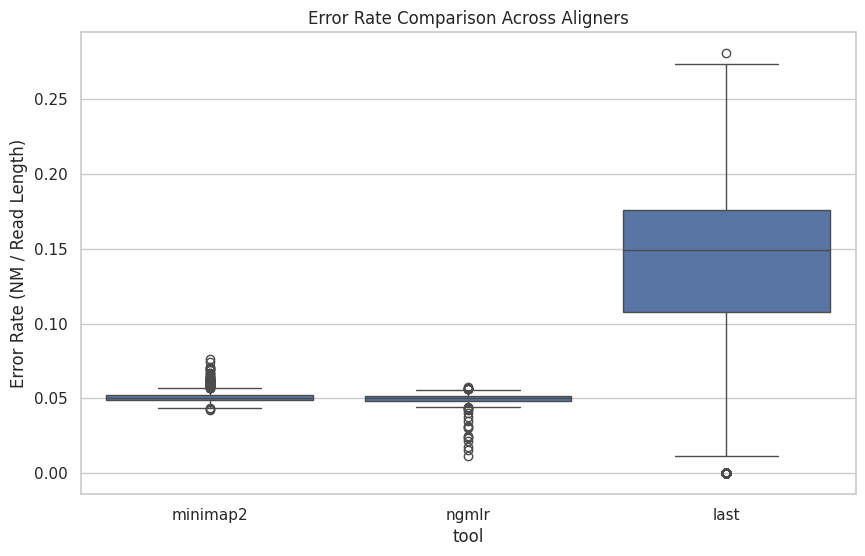

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x="tool", y="error_rate")
plt.title("Error Rate Comparison Across Aligners")
plt.ylabel("Error Rate (NM / Read Length)")
plt.savefig("results/plot_error_rate.png", dpi=300)
plt.show()


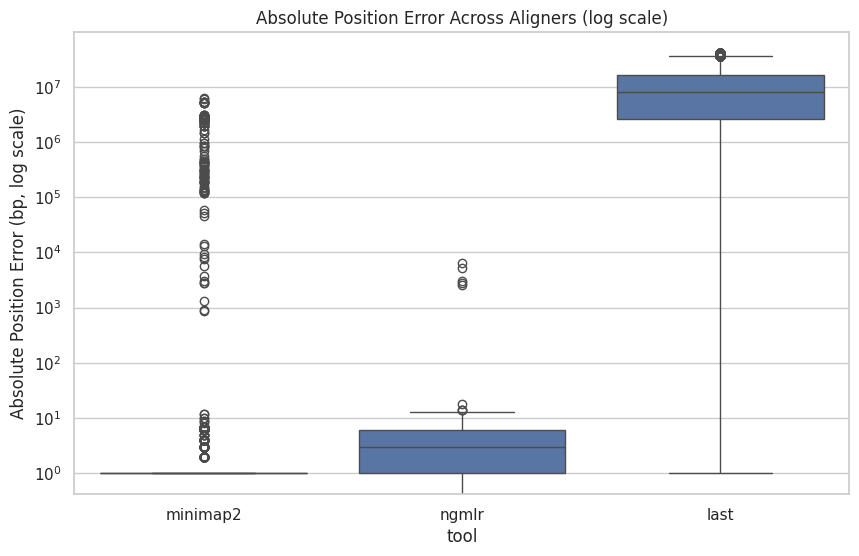

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x="tool", y="abs_pos_error")
plt.yscale("log")   # log scale because errors vary a lot
plt.title("Absolute Position Error Across Aligners (log scale)")
plt.ylabel("Absolute Position Error (bp, log scale)")
plt.savefig("results/plot_abs_pos_error.png", dpi=300)
plt.show()


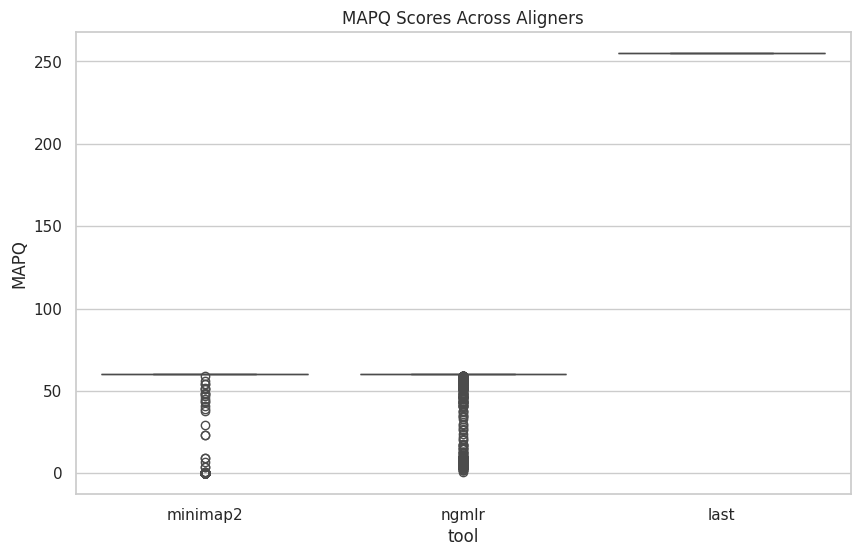

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x="tool", y="mapq")
plt.title("MAPQ Scores Across Aligners")
plt.ylabel("MAPQ")
plt.savefig("results/plot_mapq.png", dpi=300)
plt.show()


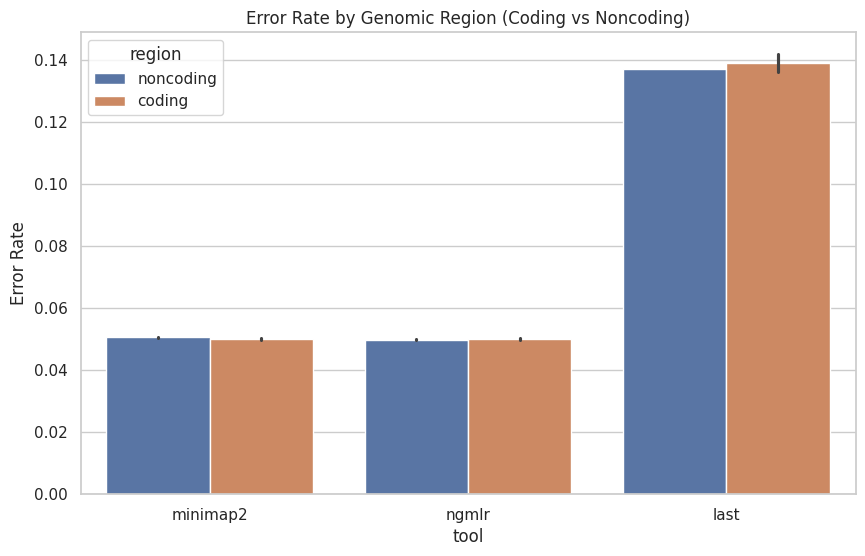

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=combined,
    x="tool",
    y="error_rate",
    hue="region"
)
plt.title("Error Rate by Genomic Region (Coding vs Noncoding)")
plt.ylabel("Error Rate")
plt.savefig("results/plot_region_error_rate.png", dpi=300)
plt.show()


In [50]:
summary = combined.groupby("tool").agg({
    "error_rate": ["mean", "median"],
    "abs_pos_error": ["mean", "median"],
    "mapq": ["mean", "median"],
    "read_name": "count"
})

summary


error_rate           abs_pos_error                   mapq         \
               mean    median          mean     median        mean median   
tool                                                                        
last       0.137055  0.149306  1.006816e+07  8128958.5  255.000000  255.0   
minimap2   0.050680  0.050300  1.422320e+05        1.0   54.702735   60.0   
ngmlr      0.049832  0.050000  1.686891e+01        3.0   55.174572   60.0   

         read_name  
             count  
tool                
last       1460186  
minimap2      1682  
ngmlr         1518